In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack
import random
from mpl_toolkits.mplot3d import Axes3D
import math
from scipy.stats import linregress
!apt-get install -y gdal-bin
!pip install GDAL


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 38 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 4s (1,308 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 127018 files and direc

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/fake_gravity_data_with_distance.csv")
data

,Distance_m,Gravity_mGal
0,0.000000,-0.377431
1,1.001001,-0.154139
2,2.002002,0.837939
3,3.003003,1.610681
4,4.004004,-0.674613
...,...,...
995,995.995996,2.323952
996,996.996997,1.950184
997,997.997998,1.918890
998,998.998999,1.848797


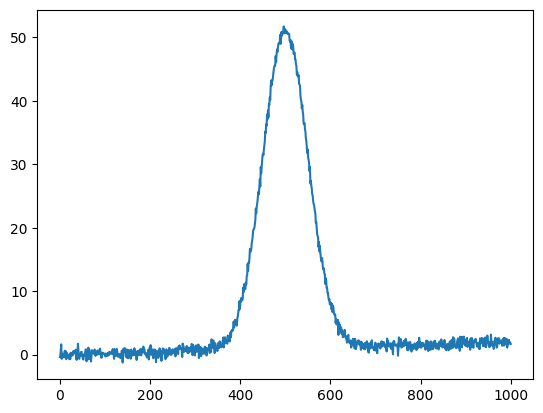

In [ ]:
plt.plot(data["Distance_m"],data["Gravity_mGal"])
gravity=data["Gravity_mGal"]

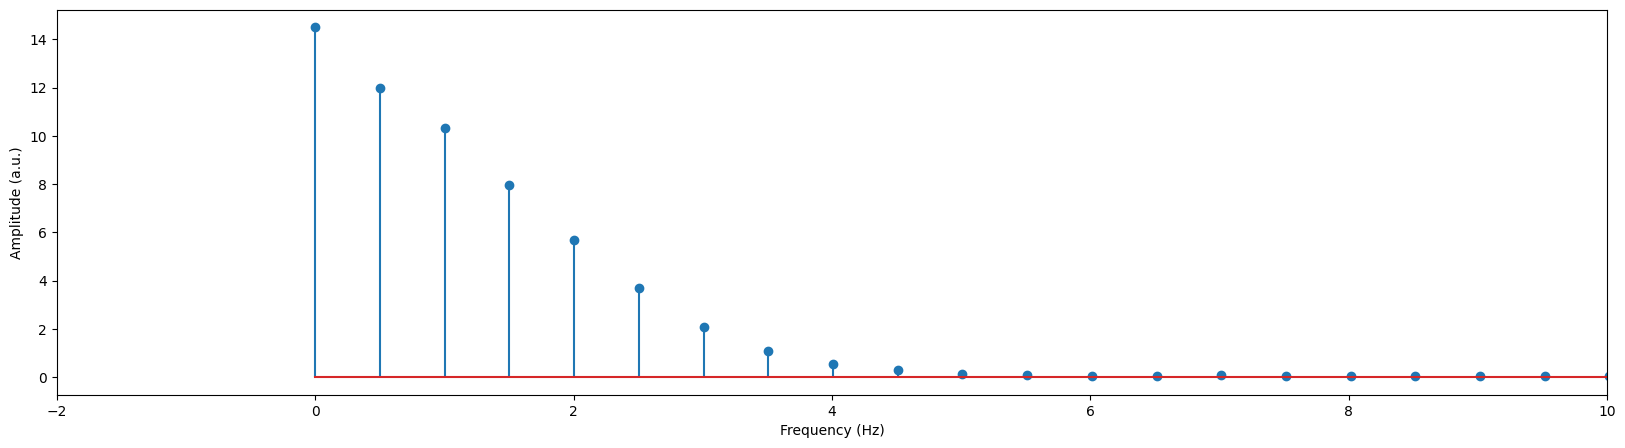

In [ ]:
g1 = data["Gravity_mGal"]

srate = 500
pnts = len(g1)
fourTime = np.arange(pnts)/pnts
fCoefs = np.zeros(pnts,dtype=complex)

for fi in range(pnts):
  csw = np.exp(-1j*2*np.pi*fi*fourTime)
  fCoefs[fi] = np.sum(gravity*csw)/pnts

ampls = 2 *np.abs(fCoefs[:pnts//2])

hz= np.linspace(0,srate/2,pnts//2)

plt.figure(figsize=(20,5))
plt.stem(hz,ampls)
plt.xlabel('Frequency (Hz)'), plt.ylabel('Amplitude (a.u.)')
plt.xlim(-2,10)
plt.show()

Estimated depth of buried source: 13.93 m


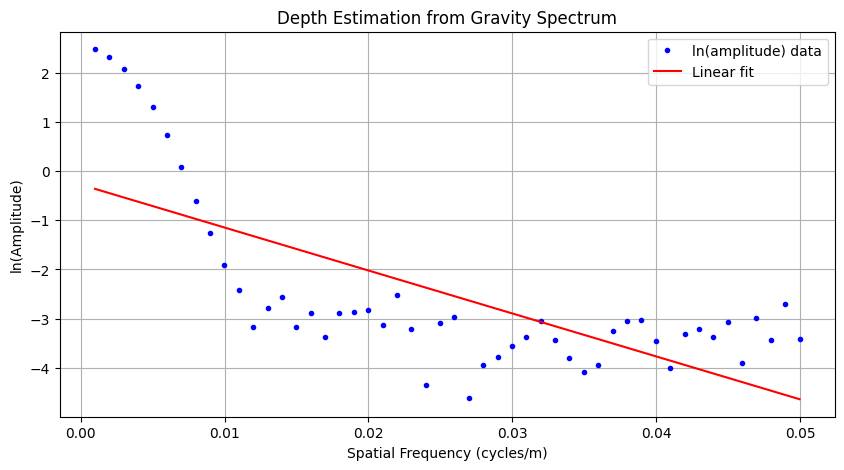

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/fake_gravity_data_with_distance.csv")
g1 = data["Gravity_mGal"].values
distance = data["Distance_m"].values
dx = distance[1] - distance[0]  # sampling interval

pnts = len(g1)

# Step 2: Compute Fourier coefficients

fourX = np.arange(pnts) / pnts
fCoefs = np.zeros(pnts, dtype=complex)
for fi in range(pnts):
    csw = np.exp(-1j * 2 * np.pi * fi * fourX)
    fCoefs[fi] = np.sum(g1 * csw) / pnts

# Amplitude spectrum (first half)
ampls = 2 * np.abs(fCoefs[:pnts//2])

# Spatial frequency axis (cycles per meter)
freqs = np.fft.fftfreq(pnts, d=dx)[:pnts//2]

# Step 3: Logarithmic Linearization

lnA = np.log(ampls[1:])          # skip zero frequency
fit_freqs = freqs[1:51]          # select linear portion for fit
fit_lnA = lnA[:50]

# Step 4: Linear Regression

slope, intercept, r_value, p_value, std_err = linregress(fit_freqs, fit_lnA)

# Depth estimation
z_est = -slope / (2 * np.pi)
print(f"Estimated depth of buried source: {z_est:.2f} m")

# Step 5: Plot ln(amplitude) vs frequency

plt.figure(figsize=(10,5))
plt.plot(fit_freqs, fit_lnA, 'b.', label="ln(amplitude) data")
plt.plot(fit_freqs, intercept + slope*fit_freqs, 'r-', label="Linear fit")
plt.xlabel("Spatial Frequency (cycles/m)")
plt.ylabel("ln(Amplitude)")
plt.title("Depth Estimation from Gravity Spectrum")
plt.legend()
plt.grid(True)
plt.show()